# Imports

In [1]:
# %matplotlib qt5

import numpy as np
import matplotlib.pyplot as plt
from pycolleff.longitudinal_equilibrium import (
    ImpedanceSource,
    LongitudinalEquilibrium,
)

from pycolleff.rings import maxiv, als, half, sirius

from pycolleff.longitudinal_equilibrium import _mytrapz

from pycolleff.colleff import Ring

import matplotlib as mplt
import matplotlib.cm as cmap

import scienceplots
from itertools import product

mplt.style.use("science")

plt.rcParams.update(
    {
        "font.size": 18,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.5,
    }
)

plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.right"] = False
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["xtick.top"] = False

c = 299_792_458

# Methods

In [2]:
def calc_equilibrium_for_fixed_detuning(
    ring, hcav, current, detune, longeq=None
):
    """Calculate the equilibrium for a fixed cavity and current."""
    h = ring.harm_num
    ring.total_current = current
    fill = np.ones(h) / h

    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring,
            impedance_sources=[
                hcav,
            ],
            fillpattern=fill,
        )
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill

    longeq.impedance_sources[0].detune_w = 2 * np.pi * detune
    _ = longeq.calc_longitudinal_equilibrium(
        niter=1_000, tol=1e-8, beta=0.1, print_flag=True, m=3
    )
    return longeq


def calc_equilibrium_for_flat_potential(
    ring, hcav, current, nr_iters=7, longeq=None
):
    """Calculate equilibrium to flat potential condition.

    This method will change the detune_angle of the cavity so that
    the beam induced voltage amplitude matches the flat potential
    condition.

    It will iterate a few times so that the form factor of the
    distribution converges.
    """
    h = ring.harm_num
    fill = np.ones(h) / h
    ring.total_current = current

    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring,
            impedance_sources=[
                hcav,
            ],
            fillpattern=fill,
        )
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill

    for _ in range(nr_iters):
        kharm = longeq.calc_harmonic_voltage_for_flat_potential()
        vharm = kharm * longeq.ring.gap_voltage
        angle = longeq.calc_detune_for_fixed_harmonic_voltage(
            vharm, Rs=hcav.shunt_impedance
        )
        hcav.detune_angle = angle
        longeq.impedance_sources[0] = hcav
        print(f"detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz")

        _ = longeq.calc_longitudinal_equilibrium(
            niter=1000, tol=1e-8, beta=0.1, print_flag=False, m=3
        )
    return longeq


###############################################################################
def calc_lmci(
    longeq,
    cbmode=1,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
):
    """Calculate LMCI for a given coupled bunch mode and equilibrium condition.

    Args:
        longeq: object from Longitudinal equilibrium class;
        cbmode: coupled-bunch mode to evaluate must be in range [0, h-1].
            Defaults to 1, which is the mode of PTBL instability;
        max_azi: maximum azimuthal mode to consider in expansion.
            Detaults to 2. Found to be enough to explain PTBL instability;
        max_azi: maximum radial mode to consider in expansion. Defaults to 1.
            Also found to be enough to explain PTBL instability.

    Returns:
        eigenfreq: complex coherent eigen angular frequencies in [rad/s];
        freqshift: frequency of the most unstable mode in [Hz];
        grate: growth rate of the most unstable mode in [1/s];
        sync_freq: incoherent synchrotron frequency used in calculations [Hz];
        peak_hvolt: peak voltage of harmonic cavity [V].

    """
    hcav = longeq.impedance_sources[0]
    hvolt = longeq.calc_induced_voltage_wake(
        dist=longeq.distributions, wake_source=hcav
    )
    mvolt = longeq.main_voltage
    tvolt = mvolt + hvolt
    peak_hvolt = np.max(np.abs(hvolt[0, :]))
    peak_mvolt = np.max(np.abs(mvolt))

    print(f"current: {longeq.ring.total_current*1e3:.2f} mA")
    print(f"detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz")
    print(f"detune angle: {np.rad2deg(hcav.detune_angle):.1f} deg")
    print(f"R/Q: {hcav.shunt_impedance/hcav.Q:.1f} Ohm")
    print(f"HC voltage: {peak_hvolt/1e3:.1f} kV")
    ratio = peak_hvolt / peak_mvolt
    print(f"HC voltage ratio: {ratio:.3f}")

    wrf = longeq.ring.rf_ang_freq
    dist, pot = longeq.calc_distributions_from_voltage(longeq.total_voltage)
    z0, sigmaz = longeq.calc_moments(longeq.zgrid, dist[0])
    sigmaz = sigmaz[0]

    # Calculate the equivalent synchrotron frequency:
    # Equivalent single-rf (quadratic) potential.
    # Sync. frequency determined by bunch length
    sync_freq = longeq.ring.espread * longeq.ring.mom_comp * c
    sync_freq /= sigmaz * 2 * np.pi
    print(f"FREQ BY BUNCH LENGTH: {sync_freq:.5f} Hz")

#     Sync. freq. by voltage derivative average by distribution
#     sync_data = longeq.calc_synchrotron_frequency(
#         method='derivative', nrpts=500, max_amp=5)
#     sync_freq = sync_data['avg_sync_freq']
#     print(f"FREQ BY V'(z): {sync_freq:.5f} Hz")

#     # Amplitude-dependent Sync. freq. averaged by action distribution
#     sync_data = longeq.calc_synchrotron_frequency(
#         method='action', nrpts=500, max_amp=5)
#     sync_freq = sync_data['avg_sync_freq']
#     print(f"FREQ BY w(J): {sync_freq:.5f} Hz")

    longeq.ring.sync_tune = sync_freq / longeq.ring.rev_freq
    longeq.ring.bunlen = sigmaz

    print(
        f"sync. freq.: {longeq.ring.sync_tune * longeq.ring.rev_freq:.3f} Hz"
    )
    print(f"bunch length: {longeq.ring.bunlen*1e3:.3f} mm")

    # Calculate Vlasov's equation eigen-frequencies:
    wrf = longeq.ring.rf_ang_freq
    eigenfreq, *_ = longeq.calc_mode_coupling(
        w=[-10 * wrf, +10 * wrf],
        cbmode=cbmode,
        max_azi=max_azi,
        max_rad=max_rad,
        use_fokker=use_fokker,
        delete_m0=delete_m0,
        delete_m0k0=delete_m0k0,
        reduced=reduced,
    )

    # Find most unstable mode:
    idx = np.argmax(eigenfreq.imag)
    freqshift = eigenfreq.real[idx] / 2 / np.pi
    grate = eigenfreq.imag[idx]
    if reduced:
        # Subtract radiation damping rate from "reduced" simulation:
        grate -= 1 / longeq.ring.dampte

    print("Most unstable mode:")
    print(f"    frequency: {freqshift:.2f} Hz")
    print(f"    growth rate: {grate:.2f} 1/s")
    print("\n")
    return eigenfreq, freqshift, grate, sync_freq, peak_hvolt


def calc_lmci_scan_current(
    ring,
    hcav,
    current_scan,
    max_azi=3,
    max_rad=2,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
):
    """Calculate equilibrium and solve Vlasov equation for a current set.

    The cavity will be detuned to flat potential condition at each current.

    """
    growths, shifts, syncdata, peak_hvolts, eigenfreqs = [], [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, current in enumerate(current_scan):
        longeq = calc_equilibrium_for_flat_potential(
            ring,
            hcav,
            current=current,
            nr_iters=8,
            longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq,
            cbmode=cbmode,
            max_azi=max_azi,
            max_rad=max_rad,
            use_fokker=use_fokker,
            delete_m0=delete_m0,
            delete_m0k0=delete_m0k0,
            reduced=reduced,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)
        eigenfreqs.append(eigenfreq)
        
        if stop_when_unstable and grate > 0:
            break
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    eigenfreqs = np.array(eigenfreqs)
    return growths, shifts, syncdata, peak_hvolts, eigenfreqs


def calc_lmci_scan_detuning(
    ring,
    hcav,
    current,
    detuning_scan,
    max_azi=3,
    max_rad=2,
    use_fokker=True,
    delete_m0=False,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
):
    """Calculate equilibrium and solve Vlasov equation for a detuning set."""
    growths, shifts, syncdata, peak_hvolts = [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, detune in enumerate(detuning_scan):
        longeq = calc_equilibrium_for_fixed_detuning(
            ring,
            hcav,
            current,
            detune=detune,
            longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq,
            cbmode=cbmode,
            max_azi=max_azi,
            max_rad=max_rad,
            use_fokker=use_fokker,
            delete_m0=delete_m0,
            delete_m0k0=delete_m0k0,
            reduced=reduced,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)
        
        if stop_when_unstable and grate > 0:
            break
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    return growths, shifts, syncdata, peak_hvolts, eigenfreq

# MAX-IV

In [3]:
ring = maxiv.create_ring(energy=3)
# ring.gap_voltage = 1.397e6

ring.gap_voltage = 1.0e6
ring.total_current = 300e-3
print(ring)

Lattice Version             :     MAX-IV-3GeV     
Circumference [m]           :       527.999       
Revolution Period [us]      :        1.761        
Revolution Frequency [kHz]  :       567.790       
Energy [GeV]                :        3.000        
U0 [keV]                    :       363.800       
Vgap [MV]                   :        1.000        
Momentum Compaction         :       3.06e-04      
Harmonic Number             :         176         
Current [mA]                :       300.000       
Current per Bunch [mA]      :        1.705        
Synchrotron Tune            :       0.00164       
Tunes x/y                   :    16.280/42.200    
Chromaticities x/y          :     1.000/1.000     
Damping Times x/y/e [ms]    :   15.7/ 29.0 /25.2  
Energy Spread [%]           :        0.0769       
Bunch Length [mm]           :        10.694       



In [4]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 20_800
# ncavs = 3

# simulating 2 harmonic cavities
ncavs = 2
hcav.shunt_impedance = 2.75e6 * ncavs

twopi = 2 * np.pi
hcav.ang_freq_rf = twopi * ring.rf_freq
hcav.ang_freq = hcav.harm_rf * hcav.ang_freq_rf

hcav.detune_w = twopi * 85e3
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive

In [5]:
current_scan = np.linspace(50, 500, 20) * 1e-3
grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_current(
    ring,
    hcav,
    current_scan,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
)

detune: 10.641 kHz
detune: 10.277 kHz
detune: 10.212 kHz
detune: 10.198 kHz
detune: 10.195 kHz
detune: 10.194 kHz
detune: 10.194 kHz
detune: 10.194 kHz
current: 50.00 mA
detune: 10.194 kHz
detune angle: 54.7 deg
R/Q: 264.4 Ohm
HC voltage: 307.6 kV
HC voltage ratio: 0.308
FREQ BY BUNCH LENGTH: 278.37316 Hz
sync. freq.: 278.373 Hz
bunch length: 40.333 mm
Most unstable mode:
    frequency: 276.68 Hz
    growth rate: -39.59 1/s


detune: 16.927 kHz
detune: 16.652 kHz
detune: 16.554 kHz
detune: 16.516 kHz
detune: 16.501 kHz
detune: 16.495 kHz
detune: 16.493 kHz
detune: 16.492 kHz
current: 73.68 mA
detune: 16.492 kHz
detune angle: 66.4 deg
R/Q: 264.4 Ohm
HC voltage: 307.6 kV
HC voltage ratio: 0.308
FREQ BY BUNCH LENGTH: 214.94539 Hz
sync. freq.: 214.945 Hz
bunch length: 52.235 mm
Most unstable mode:
    frequency: 210.56 Hz
    growth rate: -39.40 1/s


detune: 22.664 kHz
detune: 22.549 kHz
detune: 22.499 kHz
detune: 22.477 kHz
detune: 22.467 kHz
detune: 22.463 kHz
detune: 22.461 kHz
detune:

detune: 120.788 kHz
detune: 120.798 kHz
detune: 120.802 kHz
detune: 120.804 kHz
detune: 120.805 kHz
detune: 120.805 kHz
detune: 120.806 kHz
current: 500.00 mA
detune: 120.806 kHz
detune angle: 86.6 deg
R/Q: 264.4 Ohm
HC voltage: 307.6 kV
HC voltage ratio: 0.308
FREQ BY BUNCH LENGTH: 199.13004 Hz
sync. freq.: 199.130 Hz
bunch length: 56.383 mm
Most unstable mode:
    frequency: 4.68 Hz
    growth rate: 943.01 1/s




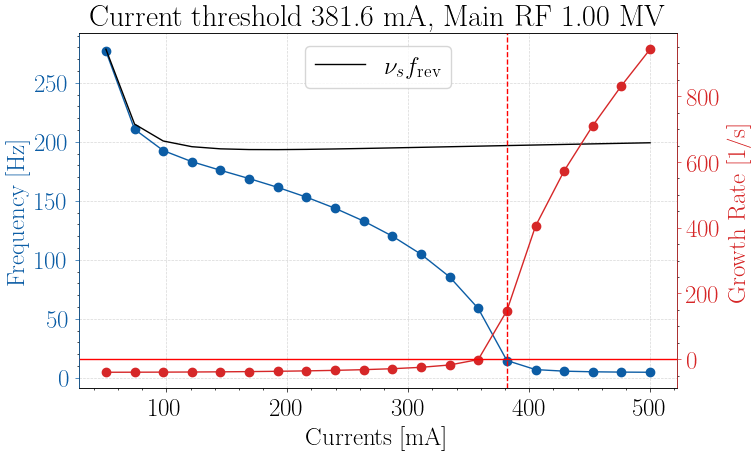

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()
ax.plot(current_scan * 1e3, freq, "o-")
ax.plot(current_scan * 1e3, sync_freq, color="k", label=r"$\nu_sf_\text{rev}$")
ay.plot(current_scan * 1e3, np.array(grate), "o-", color="tab:red")
thre = current_scan[np.argmax(grate > 0)] * 1e3
ay.axhline(0, ls='-', color='r')
ay.axvline(thre, ls='--', color='r')
ay.set_title(f"Current threshold {thre:.1f} mA, Main RF {ring.gap_voltage/1e6:.2f} MV")

ay.grid(False)
ay.spines["right"].set_color("tab:red")
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis="y", colors="tab:red")

ay.spines["left"].set_color("C0")
plt.setp(ax.yaxis.get_ticklabels(), color="tab:red")
ax.tick_params(axis="y", colors="C0")

ax.legend(loc="upper center", frameon=True)
# ay.legend(loc="center left", frameon=True)
ax.set_ylabel("Frequency [Hz]", color="C0")
ax.set_xlabel("Currents [mA]")
ay.set_ylabel("Growth Rate [1/s]", color="tab:red")
fig.tight_layout()
plt.show()

In [7]:
current_scan = np.linspace(300, 400, 31) * 1e-3
main_rf = np.linspace(900, 1100, 11) * 1e3
thresholds = []

for rf in main_rf:
    ring.gap_voltage = rf
    grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_current(
        ring,
        hcav,
        current_scan,
        max_azi=2,
        max_rad=1,
        use_fokker=True,
        delete_m0=True,
        delete_m0k0=True,
        reduced=False,
        stop_when_unstable=True,
    )
    idx_unstable = np.argmax(grate > 0)
    thre = current_scan[idx_unstable] * 1e3
    current_scan = current_scan[idx_unstable:]
    print(rf/1000, thre)
    thresholds.append(thre)
    
thresholds = np.array(thresholds)

detune: 87.174 kHz
detune: 83.692 kHz
detune: 82.484 kHz
detune: 81.969 kHz
detune: 81.734 kHz
detune: 81.624 kHz
detune: 81.572 kHz
detune: 81.547 kHz
current: 300.00 mA
detune: 81.547 kHz
detune angle: 84.9 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 189.78919 Hz
sync. freq.: 189.789 Hz
bunch length: 59.158 mm
Most unstable mode:
    frequency: 89.63 Hz
    growth rate: -20.84 1/s


detune: 82.448 kHz
detune: 82.445 kHz
detune: 82.443 kHz
detune: 82.442 kHz
detune: 82.442 kHz
detune: 82.442 kHz
detune: 82.442 kHz
detune: 82.442 kHz
current: 303.33 mA
detune: 82.442 kHz
detune angle: 85.0 deg
R/Q: 264.4 Ohm
HC voltage: 271.1 kV
HC voltage ratio: 0.301
FREQ BY BUNCH LENGTH: 189.68804 Hz
sync. freq.: 189.688 Hz
bunch length: 59.190 mm
Most unstable mode:
    frequency: 86.08 Hz
    growth rate: -19.49 1/s


detune: 83.355 kHz
detune: 83.357 kHz
detune: 83.359 kHz
detune: 83.359 kHz
detune: 83.359 kHz
detune: 83.360 kHz
detune: 83.360 kHz
detune:

detune: 88.372 kHz
detune: 87.166 kHz
detune: 86.654 kHz
detune: 86.422 kHz
detune: 86.313 kHz
detune: 86.262 kHz
detune: 86.237 kHz
current: 350.00 mA
detune: 86.237 kHz
detune angle: 85.2 deg
R/Q: 264.4 Ohm
HC voltage: 300.3 kV
HC voltage ratio: 0.306
FREQ BY BUNCH LENGTH: 195.23345 Hz
sync. freq.: 195.233 Hz
bunch length: 57.509 mm
Most unstable mode:
    frequency: 62.03 Hz
    growth rate: -4.12 1/s


detune: 87.053 kHz
detune: 87.049 kHz
detune: 87.048 kHz
detune: 87.047 kHz
detune: 87.046 kHz
detune: 87.046 kHz
detune: 87.046 kHz
detune: 87.046 kHz
current: 353.33 mA
detune: 87.046 kHz
detune angle: 85.3 deg
R/Q: 264.4 Ohm
HC voltage: 300.4 kV
HC voltage ratio: 0.306
FREQ BY BUNCH LENGTH: 195.12561 Hz
sync. freq.: 195.126 Hz
bunch length: 57.541 mm
Most unstable mode:
    frequency: 56.55 Hz
    growth rate: 0.41 1/s


980.0 353.3333333333333
detune: 90.546 kHz
detune: 87.146 kHz
detune: 85.970 kHz
detune: 85.470 kHz
detune: 85.244 kHz
detune: 85.138 kHz
detune: 85.088 kHz
detun

In [8]:
# From PRAB paper https://journals.aps.org/prab/pdf/10.1103/PhysRevAccelBeams.27.044403

maxiv_data_curr = [399, 394, 390, 385, 380, 375, 370, 365, 360]
maxiv_data_main_rf = [1070, 1050, 1035, 1020, 1010, 995, 985, 965, 945]

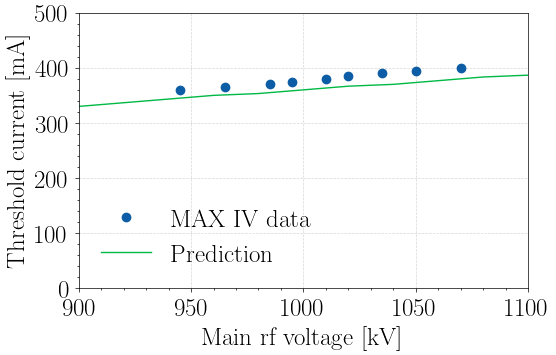

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(maxiv_data_main_rf, maxiv_data_curr, 'o', label='MAX IV data')
plt.plot(main_rf/1e3, thresholds, label='Prediction')
plt.legend()
# use the same y-scale of Fig. 11 from the paper.
plt.ylim([0, 500])
plt.xlim([900, 1100])
plt.xlabel('Main rf voltage [kV]')
plt.ylabel('Threshold current [mA]')
plt.tight_layout()
plt.show()

In [10]:
current = 360e-3
detune_scan = np.linspace(150, 80, 31) * 1e3
ring.gap_voltage = 1.0e6

grate, freq, sync_freq, peak_hvolt, eigs = calc_lmci_scan_detuning(
    ring,
    hcav,
    current,
    detune_scan,
    max_azi=2,
    max_rad=1,
    use_fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    reduced=False,
    stop_when_unstable=False,
)

Iter.: 001, Dist. Diff.: 1.469e-01 (bucket 000), E.T.: 0.021s
--------------------
Iter.: 002, Dist. Diff.: 1.111e-01 (bucket 000), E.T.: 0.022s
--------------------
Iter.: 003, Dist. Diff.: 2.308e-02 (bucket 000), E.T.: 0.021s
--------------------
Iter.: 004, Dist. Diff.: 1.783e-02 (bucket 004), E.T.: 0.022s
--------------------
Iter.: 005, Dist. Diff.: 1.490e-03 (bucket 000), E.T.: 0.021s
--------------------
Iter.: 006, Dist. Diff.: 3.500e-05 (bucket 004), E.T.: 0.020s
--------------------
Iter.: 007, Dist. Diff.: 3.136e-05 (bucket 004), E.T.: 0.019s
--------------------
Iter.: 008, Dist. Diff.: 7.203e-06 (bucket 001), E.T.: 0.022s
--------------------
Iter.: 009, Dist. Diff.: 6.142e-06 (bucket 000), E.T.: 0.020s
--------------------
Iter.: 010, Dist. Diff.: 5.080e-06 (bucket 000), E.T.: 0.020s
--------------------
Iter.: 011, Dist. Diff.: 3.750e-06 (bucket 012), E.T.: 0.020s
--------------------
Iter.: 012, Dist. Diff.: 2.952e-06 (bucket 004), E.T.: 0.021s
--------------------
Iter

Iter.: 003, Dist. Diff.: 2.834e-03 (bucket 007), E.T.: 0.020s
--------------------
Iter.: 004, Dist. Diff.: 1.237e-04 (bucket 015), E.T.: 0.020s
--------------------
Iter.: 005, Dist. Diff.: 6.079e-08 (bucket 013), E.T.: 0.020s
--------------------
Iter.: 006, Dist. Diff.: 5.471e-08 (bucket 013), E.T.: 0.019s
--------------------
Iter.: 007, Dist. Diff.: 5.086e-10 (bucket 000), E.T.: 0.019s
--------------------
distribution ok!
current: 360.00 mA
detune: 131.333 kHz
detune angle: 86.9 deg
R/Q: 264.4 Ohm
HC voltage: 215.1 kV
HC voltage ratio: 0.215
FREQ BY BUNCH LENGTH: 523.54841 Hz
sync. freq.: 523.548 Hz
bunch length: 21.445 mm
Most unstable mode:
    frequency: 485.79 Hz
    growth rate: -33.83 1/s


Iter.: 001, Dist. Diff.: 1.130e-02 (bucket 003), E.T.: 0.018s
--------------------
Iter.: 002, Dist. Diff.: 3.269e-03 (bucket 003), E.T.: 0.019s
--------------------
Iter.: 003, Dist. Diff.: 3.196e-03 (bucket 010), E.T.: 0.020s
--------------------
Iter.: 004, Dist. Diff.: 1.806e-04 (buc

Iter.: 004, Dist. Diff.: 1.919e-04 (bucket 000), E.T.: 0.019s
--------------------
Iter.: 005, Dist. Diff.: 1.405e-06 (bucket 006), E.T.: 0.019s
--------------------
Iter.: 006, Dist. Diff.: 3.271e-07 (bucket 001), E.T.: 0.018s
--------------------
Iter.: 007, Dist. Diff.: 2.947e-07 (bucket 000), E.T.: 0.020s
--------------------
Iter.: 008, Dist. Diff.: 4.698e-08 (bucket 010), E.T.: 0.020s
--------------------
Iter.: 009, Dist. Diff.: 2.915e-08 (bucket 012), E.T.: 0.019s
--------------------
Iter.: 010, Dist. Diff.: 2.627e-08 (bucket 013), E.T.: 0.018s
--------------------
Iter.: 011, Dist. Diff.: 1.029e-08 (bucket 001), E.T.: 0.020s
--------------------
Iter.: 012, Dist. Diff.: 5.727e-09 (bucket 002), E.T.: 0.020s
--------------------
distribution ok!
current: 360.00 mA
detune: 110.333 kHz
detune angle: 86.3 deg
R/Q: 264.4 Ohm
HC voltage: 254.4 kV
HC voltage ratio: 0.254
FREQ BY BUNCH LENGTH: 407.60572 Hz
sync. freq.: 407.606 Hz
bunch length: 27.545 mm
Most unstable mode:
    frequen

Iter.: 002, Dist. Diff.: 7.470e-02 (bucket 002), E.T.: 0.020s
--------------------
Iter.: 003, Dist. Diff.: 3.384e-02 (bucket 015), E.T.: 0.021s
--------------------
Iter.: 004, Dist. Diff.: 2.252e-02 (bucket 015), E.T.: 0.020s
--------------------
Iter.: 005, Dist. Diff.: 3.983e-04 (bucket 012), E.T.: 0.020s
--------------------
Iter.: 006, Dist. Diff.: 2.442e-04 (bucket 015), E.T.: 0.020s
--------------------
Iter.: 007, Dist. Diff.: 2.190e-04 (bucket 003), E.T.: 0.018s
--------------------
Iter.: 008, Dist. Diff.: 1.044e-04 (bucket 001), E.T.: 0.019s
--------------------
Iter.: 009, Dist. Diff.: 1.383e-05 (bucket 002), E.T.: 0.019s
--------------------
Iter.: 010, Dist. Diff.: 8.314e-07 (bucket 012), E.T.: 0.018s
--------------------
Iter.: 011, Dist. Diff.: 7.414e-07 (bucket 006), E.T.: 0.020s
--------------------
Iter.: 012, Dist. Diff.: 3.446e-07 (bucket 004), E.T.: 0.019s
--------------------
Iter.: 013, Dist. Diff.: 3.012e-07 (bucket 010), E.T.: 0.018s
--------------------
Iter

current: 360.00 mA
detune: 89.333 kHz
detune angle: 85.4 deg
R/Q: 264.4 Ohm
HC voltage: 302.4 kV
HC voltage ratio: 0.302
FREQ BY BUNCH LENGTH: 219.32371 Hz
sync. freq.: 219.324 Hz
bunch length: 51.192 mm
Most unstable mode:
    frequency: 122.98 Hz
    growth rate: -22.71 1/s


Iter.: 001, Dist. Diff.: 4.605e-01 (bucket 007), E.T.: 0.019s
--------------------
Iter.: 002, Dist. Diff.: 1.888e-01 (bucket 015), E.T.: 0.021s
--------------------
Iter.: 003, Dist. Diff.: 1.440e-01 (bucket 009), E.T.: 0.019s
--------------------
Iter.: 004, Dist. Diff.: 1.391e-01 (bucket 015), E.T.: 0.020s
--------------------
Iter.: 005, Dist. Diff.: 7.121e-02 (bucket 011), E.T.: 0.018s
--------------------
Iter.: 006, Dist. Diff.: 1.571e-02 (bucket 005), E.T.: 0.020s
--------------------
Iter.: 007, Dist. Diff.: 6.176e-03 (bucket 009), E.T.: 0.022s
--------------------
Iter.: 008, Dist. Diff.: 2.969e-03 (bucket 011), E.T.: 0.018s
--------------------
Iter.: 009, Dist. Diff.: 2.127e-03 (bucket 011), E.T.: 0.

Iter.: 001, Dist. Diff.: 1.362e+00 (bucket 007), E.T.: 0.018s
--------------------
Iter.: 002, Dist. Diff.: 1.128e+00 (bucket 007), E.T.: 0.018s
--------------------
Iter.: 003, Dist. Diff.: 7.848e-01 (bucket 001), E.T.: 0.018s
--------------------
Iter.: 004, Dist. Diff.: 9.722e-01 (bucket 008), E.T.: 0.020s
--------------------
Iter.: 005, Dist. Diff.: 3.228e-01 (bucket 008), E.T.: 0.020s
--------------------
Iter.: 006, Dist. Diff.: 2.448e-01 (bucket 008), E.T.: 0.018s
--------------------
Iter.: 007, Dist. Diff.: 1.394e-01 (bucket 004), E.T.: 0.019s
--------------------
Iter.: 008, Dist. Diff.: 5.254e-02 (bucket 011), E.T.: 0.019s
--------------------
Iter.: 009, Dist. Diff.: 3.572e-02 (bucket 011), E.T.: 0.018s
--------------------
Iter.: 010, Dist. Diff.: 1.933e-02 (bucket 015), E.T.: 0.018s
--------------------
Iter.: 011, Dist. Diff.: 1.132e-02 (bucket 015), E.T.: 0.020s
--------------------
Iter.: 012, Dist. Diff.: 9.367e-03 (bucket 011), E.T.: 0.021s
--------------------
Iter

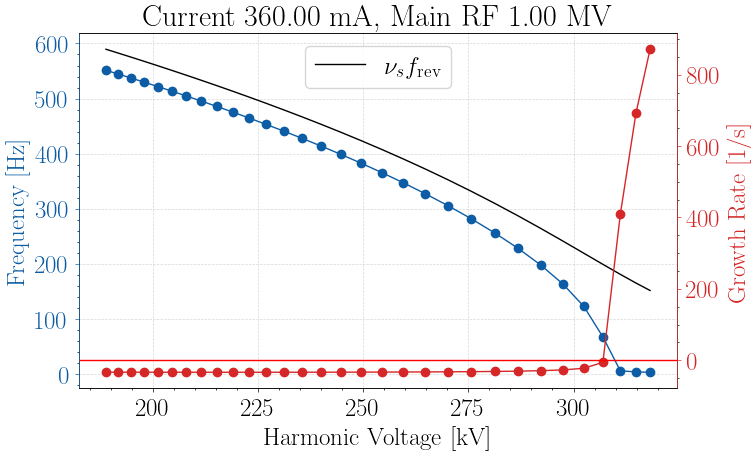

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()

norm = 1
ax.plot(peak_hvolt * 1e-3 / norm, freq, "o-")
ax.plot(peak_hvolt * 1e-3 / norm, sync_freq, color="k", label=r"$\nu_sf_{\text{rev}}$")
ay.plot(peak_hvolt * 1e-3 / norm, grate, "o-", color="tab:red")

ay.axhline(0, color='r')
ax.set_title(f"Current {current*1e3:.2f} mA, Main RF {ring.gap_voltage/1e6:.2f} MV")
# ax.axvline(448.181)

ay.grid(False)
ay.spines["right"].set_color("tab:red")
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis="y", colors="tab:red")

ay.spines["left"].set_color("C0")
plt.setp(ax.yaxis.get_ticklabels(), color="tab:red")
ax.tick_params(axis="y", colors="C0")

ax.legend(loc="upper center", frameon=True)
ax.set_ylabel("Frequency [Hz]", color="C0")
ax.set_xlabel("Harmonic Voltage [kV]")
ay.set_ylabel("Growth Rate [1/s]", color="tab:red")
fig.tight_layout()
plt.show()